# MeteoSwiss reference precipitation — Ehrendingen (OED), 2004-2025

***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Reference station**: Ehrendingen (OED), MeteoSwiss
**Products**: daily 2004-2014, 30MIN 2014-2025
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

> **Source: MeteoSwiss.** These data are free to use, but the source must be cited whenever they
> are reproduced or redistributed. Keep this attribution with any figure or derived product.

## ℹ️ About this notebook
Downloads precipitation from the MeteoSwiss open-data STAC API for station **Ehrendingen (OED)**
and writes two reference products for comparison against the tower gauge `PREC_TOT_T1_47_1`.

This notebook **does not touch the InfluxDB database** and screens nothing. It only fetches an
independent reference series and puts it on our time axis.

**Why OED and not LAE.** The Lägern SMN station (`lae`) is the obvious candidate — it is on the
same ridge and its 10-min files go back to Feb 2004 — but **it does not measure precipitation at
all**: `rre150z0` is empty in every 10-min record and `rre150d0` is empty across all 13,190 daily
records from 1989 to 2025. OED, 3.8 km NNW of the tower, is the nearest MeteoSwiss gauge.

**Why two resolutions.** OED's sub-daily data only begins **09 Sep 2014**. Before that only daily
values exist (they run back to 1975). So the reference is necessarily:

| Period | Resolution | Source file |
|---|---|---|
| 2004-01-01 → 2014-09-09 | daily | `ogd-smn-precip_oed_d_historical.csv` |
| 2014-09-10 → 2025-12-31 | 30MIN (aggregated from 10-min) | `ogd-smn-precip_oed_t_historical_*.csv` |

The two are spliced at a MeteoSwiss precip-day boundary so they neither overlap nor leave a gap.

## ⏱️ Timestamp convention (important)
MeteoSwiss publishes **all** reference timestamps in **UTC**. Two separate conventions apply, and
mixing them up silently shifts the reference against our data:

**10-min values** — `reference_timestamp` marks the **end** of the 10-minute interval, so a record
at `t` covers `(t-10min, t]`. This matches our database's `TIMESTAMP_END`, so the 30MIN product is
simply shifted by `TIMEZONE_OFFSET_TO_UTC_HOURS` into local time and carries `TIMESTAMP_END`.

**Daily values** — the MeteoSwiss precipitation day runs **06 UTC → 06 UTC**, and the value
labelled day `D` covers `[D 06:00 UTC, D+1 06:00 UTC)`. This is *not* a local-midnight day, so the
daily product is **left on its native MeteoSwiss day** and **not** shifted. Do not compare it
against a local-midnight daily sum of our tower data without re-aggregating ours the same way.

Both conventions were verified empirically rather than taken on trust — see *Validation* below.

## ✏️ Settings

In [ ]:
# --- Reference station ---
STAC_COLLECTION = 'ch.meteoschweiz.ogd-smn-precip'  # (!) OED is in the precip-only network,
STAC_STATION = 'oed'                                #     NOT in 'ch.meteoschweiz.ogd-smn'
PARAM_HIRES = 'rre150z0'  # precipitation sum, 10-min [mm]
PARAM_DAILY = 'rre150d0'  # precipitation sum, daily [mm]

# --- Period ---
START = '2004-01-01'  # included
STOP = '2026-01-01'  # not included

# --- Time axis ---
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET), same value the meteo notebooks use
MS_DAY_START_UTC = 6  # MeteoSwiss precipitation day runs 06 UTC -> 06 UTC
TARGET_FREQ = '30min'

# --- Output ---
# Mirrors this notebook's own path under the external data folder, per the repo
# convention: a data file carries the same relative path as the code that produces it.
OUTDIR = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
          r'\workflow\10_METEO\00_meteoscreening_diive\PREC')
OUTNAME_DAILY = 'PREC_MeteoSwiss_OED_DAILY'
OUTNAME_HIRES = 'PREC_MeteoSwiss_OED_30MIN'
EXPORT_FORMATS = ('parquet', 'csv')  # parquet keeps dtypes/index; csv is for eyeballing and sharing

### Imports

In [2]:
import io
import json
import urllib.request
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 1000)
print(f"Last run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f'pandas v{pd.__version__}')

Last run: 2026-07-20 15:44:41
pandas v3.0.3


## 🔧 Helpers
`stac_assets` resolves the station's STAC item to a `{filename: url}` map; `read_ms_csv` reads one
MeteoSwiss CSV into a UTC-indexed frame.

In [3]:
STAC_ITEM_URL = f'https://data.geo.admin.ch/api/stac/v1/collections/{STAC_COLLECTION}/items/{STAC_STATION}'


def stac_assets(url: str) -> dict:
    """Return {filename: href} for a STAC item. Raises if the item has no assets."""
    with urllib.request.urlopen(url) as r:
        item = json.load(r)
    assets = {k: v['href'] for k, v in item.get('assets', {}).items()}
    if not assets:
        raise ValueError(f'STAC item {url} exposes no assets - wrong collection or station?')
    return assets


def read_ms_csv(href: str, param: str) -> pd.Series:
    """Read one MeteoSwiss CSV and return *param* as a UTC-indexed, sorted Series."""
    with urllib.request.urlopen(href) as r:
        df = pd.read_csv(io.BytesIO(r.read()), sep=';')
    if param not in df.columns:
        raise ValueError(f'{param} not in {href} (has: {list(df.columns)})')
    df['TIMESTAMP'] = pd.to_datetime(df['reference_timestamp'], format='%d.%m.%Y %H:%M')
    return df.set_index('TIMESTAMP')[param].sort_index()

### Negative control
Both helpers can fail quietly if the station or parameter is wrong — an empty asset map reads as
"no files yet", a missing column as "no data". Prove they raise instead.

In [4]:
# Wrong collection: OED does not exist in the standard weather-station network.
try:
    stac_assets('https://data.geo.admin.ch/api/stac/v1/collections/ch.meteoschweiz.ogd-smn/items/oed')
except Exception as e:
    print(f'PASSED - wrong collection raises: {type(e).__name__}')
else:
    raise AssertionError('(!) FAILED - stac_assets accepted a station that does not exist')

# Wrong parameter: LAE-style radiation code is not in an OED precip file.
_assets = stac_assets(STAC_ITEM_URL)
try:
    read_ms_csv(_assets['ogd-smn-precip_oed_d_historical.csv'], 'gre000d0')
except ValueError as e:
    print(f'PASSED - unknown parameter raises: {e}'[:110])
else:
    raise AssertionError('(!) FAILED - read_ms_csv accepted a parameter that is not in the file')

PASSED - wrong collection raises: HTTPError
PASSED - unknown parameter raises: gre000d0 not in https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn-precip/oe


## ⬇️ Available files

In [5]:
assets = stac_assets(STAC_ITEM_URL)
print(f'Station: {STAC_STATION.upper()}  |  collection: {STAC_COLLECTION}')
for k in sorted(assets):
    print(f'  {k}')

Station: OED  |  collection: ch.meteoschweiz.ogd-smn-precip
  ogd-smn-precip_oed_d_historical.csv
  ogd-smn-precip_oed_d_recent.csv
  ogd-smn-precip_oed_h_historical_2010-2019.csv
  ogd-smn-precip_oed_h_historical_2020-2029.csv
  ogd-smn-precip_oed_h_now.csv
  ogd-smn-precip_oed_h_recent.csv
  ogd-smn-precip_oed_m.csv
  ogd-smn-precip_oed_t_historical_2010-2019.csv
  ogd-smn-precip_oed_t_historical_2020-2029.csv
  ogd-smn-precip_oed_t_now.csv
  ogd-smn-precip_oed_t_recent.csv
  ogd-smn-precip_oed_y.csv


## 📅 Daily product (2004 → handover)
One file covers 1975 to the end of last year, so nothing needs concatenating here.

In [6]:
daily_all = read_ms_csv(assets[f'ogd-smn-precip_{STAC_STATION}_d_historical.csv'], PARAM_DAILY)
print(f'Daily file: {len(daily_all)} days, {daily_all.index[0].date()} -> {daily_all.index[-1].date()}')
print(f'Requested period: {daily_all[START:].index[0].date()} onwards')

Daily file: 18628 days, 1975-01-01 -> 2025-12-31
Requested period: 2004-01-01 onwards


## ⏲️ 30MIN product (handover → 2025)
The decade files are concatenated, put on a **gapless 10-min grid** (missing records are *absent
rows* in the source, not NaN rows — without the reindex they would vanish instead of being
counted), then summed to 30MIN.

Binning: with end-labelled stamps the 30MIN period ending at `T` holds the records `T-20`, `T-10`,
`T` — which is exactly `closed='right', label='right'`. `min_count=3` makes any half-hour with a
missing record NaN rather than a silent under-sum.

In [7]:
hires_files = sorted(k for k in assets if '_t_historical_' in k)
print(f'Concatenating: {hires_files}')
hires = pd.concat([read_ms_csv(assets[k], PARAM_HIRES) for k in hires_files]).sort_index()
hires = hires[~hires.index.duplicated(keep='first')]
print(f'10MIN raw: {len(hires)} records, {hires.index[0]} -> {hires.index[-1]} (UTC)')

hires = hires.reindex(pd.date_range(hires.index[0], hires.index[-1], freq='10min'))
print(f'On gapless grid: {len(hires)} records, {hires.isna().sum()} missing '
      f'({hires.isna().mean() * 100:.2f}%)')

Concatenating: ['ogd-smn-precip_oed_t_historical_2010-2019.csv', 'ogd-smn-precip_oed_t_historical_2020-2029.csv']
10MIN raw: 594148 records, 2014-09-09 12:50:00 -> 2025-12-31 23:50:00 (UTC)
On gapless grid: 594931 records, 783 missing (0.13%)


In [8]:
_res = hires.resample(TARGET_FREQ, label='right', closed='right')
prec30 = pd.DataFrame({'PREC_OED_MS': _res.sum(min_count=3), 'N_RECORDS': _res.count()})
print(f'{TARGET_FREQ}: {len(prec30)} periods, {prec30.index[0]} -> {prec30.index[-1]} (UTC)')

30min: 198311 periods, 2014-09-09 13:00:00 -> 2026-01-01 00:00:00 (UTC)


#### Guard: prove the binning
`closed`/`label` are easy to get subtly wrong and the result still looks plausible. Assert that one
hand-checked half-hour really is the sum of the three expected 10-min records.

In [9]:
# Probe a WET half-hour on purpose: a dry one sums to 0.0 and the assertion below
# would pass no matter how the bins were labelled.
_wet_periods = prec30[(prec30['N_RECORDS'] == 3) & (prec30['PREC_OED_MS'] > 0)]
_probe = _wet_periods.index[len(_wet_periods) // 2]
_expected_stamps = [_probe - pd.Timedelta(minutes=20), _probe - pd.Timedelta(minutes=10), _probe]
_expected = hires.loc[_expected_stamps]

assert prec30.loc[_probe, 'N_RECORDS'] == 3, '(!) FAILED - probe period is not complete'
assert _expected.sum() > 0, '(!) FAILED - probe period is dry, the check would be vacuous'
assert abs(prec30.loc[_probe, 'PREC_OED_MS'] - _expected.sum()) < 1e-9, '(!) FAILED - binning is off'

# Also prove the neighbouring records are NOT in this bin (catches an off-by-one
# that a sum-only check would miss when the neighbour happens to be dry).
_neighbour = hires.loc[_probe + pd.Timedelta(minutes=10)]
assert abs(prec30.loc[_probe, 'PREC_OED_MS'] - (_expected.sum() + _neighbour)) > 1e-9 or _neighbour == 0
print(f'PASSED - period ending {_probe} = records '
      f'{[s.strftime("%H:%M") for s in _expected_stamps]} '
      f'= {list(_expected.values)} = {_expected.sum():.1f} mm')

PASSED - period ending 2020-06-14 03:00:00 = records ['02:40', '02:50', '03:00'] = [np.float64(0.1), np.float64(0.0), np.float64(0.0)] = 0.1 mm


## 🔗 Splice the two products
The daily day `D` covers `[D 06:00 UTC, D+1 06:00 UTC)`, so handing over at the first such boundary
at or after the first complete 30MIN period gives a seam with **no gap and no overlap**.

In [10]:
first_complete = prec30.index[prec30['N_RECORDS'] == 3][0]
handover = first_complete.normalize() + pd.Timedelta(hours=MS_DAY_START_UTC)
if handover < first_complete:
    handover += pd.Timedelta(days=1)
last_daily_day = handover.normalize() - pd.Timedelta(days=1)

daily_out = daily_all[(daily_all.index >= START) & (daily_all.index <= last_daily_day)].copy()
hires_out = prec30[(prec30.index > handover) & (prec30.index < STOP)].copy()

print(f'First complete {TARGET_FREQ} period: {first_complete} UTC')
print(f'Handover boundary:              {handover} UTC\n')
print(f'DAILY : {daily_out.index[0].date()} -> {daily_out.index[-1].date()}  '
      f'({len(daily_out)} days, {daily_out.isna().sum()} NaN, {daily_out.sum():.1f} mm)')
print(f'30MIN : {hires_out.index[0]} -> {hires_out.index[-1]}  '
      f'({len(hires_out)} periods, {hires_out["PREC_OED_MS"].isna().sum()} NaN, '
      f'{hires_out["PREC_OED_MS"].sum():.1f} mm)')

First complete 30min period: 2014-09-09 13:30:00 UTC
Handover boundary:              2014-09-10 06:00:00 UTC

DAILY : 2004-01-01 -> 2014-09-09  (3905 days, 0 NaN, 11841.7 mm)
30MIN : 2014-09-10 06:30:00 -> 2025-12-31 23:30:00  (198275 periods, 262 NaN, 10598.7 mm)


### Sanity checks

In [11]:
# 30MIN axis is continuous, unique and at the expected resolution.
assert hires_out.index.is_monotonic_increasing, '(!) index not sorted'
assert not hires_out.index.has_duplicates, '(!) duplicate timestamps'
assert pd.infer_freq(hires_out.index) == TARGET_FREQ, f'(!) not {TARGET_FREQ}'
# Precipitation is non-negative and finite.
assert (hires_out['PREC_OED_MS'].dropna() >= 0).all(), '(!) negative precipitation'
assert (daily_out.dropna() >= 0).all(), '(!) negative daily precipitation'
# The seam must not double-count or skip.
assert last_daily_day + pd.Timedelta(days=1) + pd.Timedelta(hours=MS_DAY_START_UTC) == handover
print('PASSED - continuous index, no duplicates, non-negative, seam is exact')

PASSED - continuous index, no duplicates, non-negative, seam is exact


## ✅ Validation
Re-aggregate the derived 30MIN series back to the MeteoSwiss precipitation day and compare against
the published daily file. This is what pins down both timestamp conventions: it only lines up if
the 10-min stamps are end-labelled **and** the daily window starts at 06 UTC.

Only **gap-free** days are compared — a day containing a NaN half-hour would under-sum and muddy
the comparison.

In [12]:
_back = hires_out['PREC_OED_MS'].shift(freq=f'-{MS_DAY_START_UTC}h').resample('D').sum()
_ok = (hires_out['N_RECORDS'] == 3).shift(freq=f'-{MS_DAY_START_UTC}h').resample('D').sum()
cmp = pd.DataFrame({'daily_file': daily_all.reindex(_back.index),
                    'from_30min': _back,
                    'complete': _ok == 48}).dropna(subset=['daily_file']).iloc[1:-1]
cmp = cmp[cmp['complete']]
_d = (cmp['from_30min'] - cmp['daily_file']).abs()

print(f'Gap-free days compared: {len(cmp)}')
print(f'  correlation      : {cmp[["daily_file", "from_30min"]].corr().iloc[0, 1]:.5f}')
print(f'  mean |difference|: {_d.mean():.4f} mm')
print(f'  max  |difference|: {_d.max():.2f} mm')
print(f'  totals           : {cmp["from_30min"].sum():.1f} mm (derived) vs '
      f'{cmp["daily_file"].sum():.1f} mm (published) '
      f'-> {(cmp["from_30min"].sum() / cmp["daily_file"].sum() - 1) * 100:+.3f}%')
assert cmp[['daily_file', 'from_30min']].corr().iloc[0, 1] > 0.99, '(!) FAILED - conventions disagree'
print('PASSED - timestamp conventions confirmed')

Gap-free days compared: 4120
  correlation      : 0.99895
  mean |difference|: 0.0679 mm
  max  |difference|: 3.00 mm
  totals           : 10596.6 mm (derived) vs 10598.0 mm (published) -> -0.013%
PASSED - timestamp conventions confirmed


The derived and published values agree in total but **not day by day**: dry days match almost
always, wet days only ~50-80% of the time, with differences of a few hundredths of a mm (rarely up
to ~3 mm). This comes from the 0.1 mm resolution of the published 10-min values accumulating over
48 half-hours. Treat the **published daily file as authoritative for daily totals** and the 30MIN
series as a derived product for sub-daily timing.

In [13]:
_wet = cmp[cmp['daily_file'] > 0]
_dry = cmp[cmp['daily_file'] == 0]
print(f'dry days: {len(_dry):5d}  exact match {( (_dry["from_30min"]-_dry["daily_file"]).abs()<0.001).mean()*100:5.1f}%')
print(f'wet days: {len(_wet):5d}  exact match {( (_wet["from_30min"]-_wet["daily_file"]).abs()<0.001).mean()*100:5.1f}%')

dry days:  2267  exact match  99.5%
wet days:  1853  exact match  64.9%


## 🌍 Shift the 30MIN product to local time

In [14]:
# 10-min stamps are end-of-interval UTC -> shift to local TIMESTAMP_END, matching our database.
# The DAILY product is deliberately NOT shifted (see 'Timestamp convention').
# Capture the covered years BEFORE shifting: the +1h push moves the last local stamp
# into 1 Jan of the following year, which would otherwise mislabel the exported file.
HIRES_YEARS = f'{hires_out.index[0]:%Y}-{hires_out.index[-1]:%Y}'
DAILY_YEARS = f'{daily_out.index[0]:%Y}-{daily_out.index[-1]:%Y}'

hires_out.index = hires_out.index + pd.Timedelta(hours=TIMEZONE_OFFSET_TO_UTC_HOURS)
hires_out.index.name = 'TIMESTAMP_END'
daily_out.index.name = 'TIMESTAMP_MS_PRECIP_DAY'
hires_out['FLAG_INCOMPLETE'] = (hires_out['N_RECORDS'] < 3).astype(int)

print(f'Covered years (UTC): DAILY {DAILY_YEARS}, 30MIN {HIRES_YEARS}')
print(f'30MIN now local (UTC+{TIMEZONE_OFFSET_TO_UTC_HOURS}): '
      f'{hires_out.index[0]} -> {hires_out.index[-1]}')
print(f'  (the last local stamp falls in {hires_out.index[-1]:%Y} because of the '
      f'+{TIMEZONE_OFFSET_TO_UTC_HOURS}h shift; it is still {HIRES_YEARS.split("-")[-1]} data)')
hires_out.head()

Covered years (UTC): DAILY 2004-2014, 30MIN 2014-2025
30MIN now local (UTC+1): 2014-09-10 07:30:00 -> 2026-01-01 00:30:00
  (the last local stamp falls in 2026 because of the +1h shift; it is still 2025 data)


,PREC_OED_MS,N_RECORDS,FLAG_INCOMPLETE
TIMESTAMP_END,,,
2014-09-10 07:30:00,0.0,3,0
2014-09-10 08:00:00,0.0,3,0
2014-09-10 08:30:00,0.0,3,0
2014-09-10 09:00:00,0.0,3,0
2014-09-10 09:30:00,0.0,3,0


## 📊 Plots

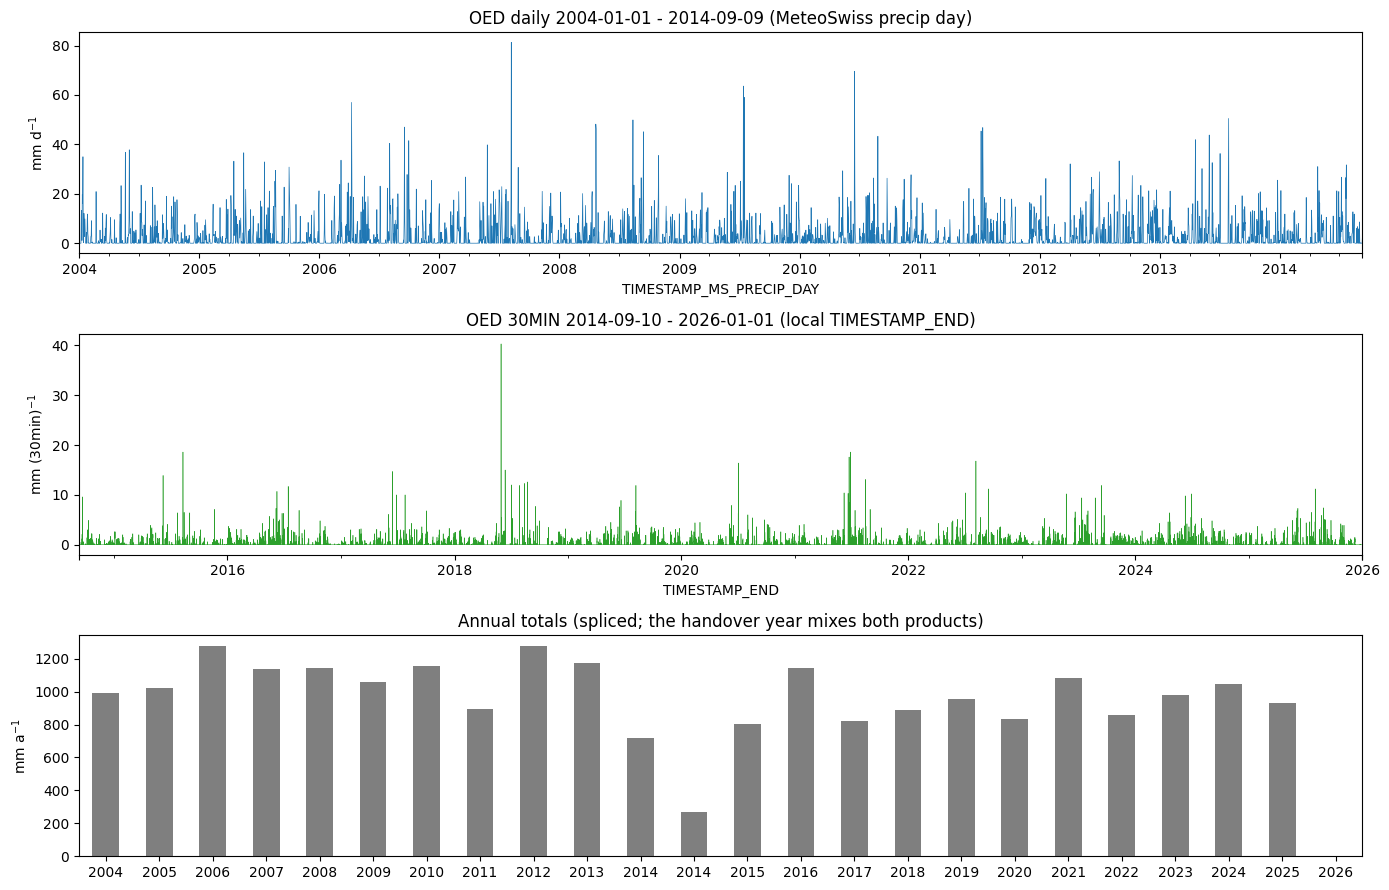

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
daily_out.plot(ax=axes[0], lw=.5, color='tab:blue')
axes[0].set_title(f'OED daily {daily_out.index[0].date()} - {daily_out.index[-1].date()} (MeteoSwiss precip day)')
axes[0].set_ylabel('mm d$^{-1}$')
hires_out['PREC_OED_MS'].plot(ax=axes[1], lw=.4, color='tab:green')
axes[1].set_title(f'OED 30MIN {hires_out.index[0].date()} - {hires_out.index[-1].date()} (local TIMESTAMP_END)')
axes[1].set_ylabel('mm (30min)$^{-1}$')
_yr = pd.concat([daily_out.resample('YS').sum(),
                 hires_out['PREC_OED_MS'].resample('YS').sum()]).sort_index()
_yr.plot(ax=axes[2], kind='bar', color='tab:grey')
axes[2].set_title('Annual totals (spliced; the handover year mixes both products)')
axes[2].set_ylabel('mm a$^{-1}$')
axes[2].set_xticklabels([t.get_text()[:4] for t in axes[2].get_xticklabels()], rotation=0)
plt.tight_layout()
plt.show()

## 💾 Export

In [ ]:
outdir = Path(OUTDIR)
outdir.mkdir(parents=True, exist_ok=True)

# Years come from the UTC axis (set before the local shift), so the 30MIN file is
# labelled by the data it holds, not by where the +1h shift lands the last stamp.
daily_export = daily_out.to_frame('PREC_OED_MS_DAILY')
exports = {f'{OUTNAME_DAILY}_{DAILY_YEARS}': daily_export,
           f'{OUTNAME_HIRES}_{HIRES_YEARS}': hires_out}

written = {}
for stem, frame in exports.items():
    for fmt in EXPORT_FORMATS:
        path = outdir / f'{stem}.{fmt}'
        if fmt == 'parquet':
            frame.to_parquet(path)
        elif fmt == 'csv':
            # index=True keeps the timestamp; NaN stays empty so a gap cannot be
            # mistaken for a dry (0 mm) record when the csv is read back elsewhere.
            frame.to_csv(path, index=True, na_rep='')
        else:
            raise ValueError(f'unsupported export format: {fmt}')
        written[(stem, fmt)] = path
        print(f'Wrote {path.name:<45s} ({path.stat().st_size / 1024:>7.0f} KB)')
print(f'\n  in {outdir}')

d_path = written[(f'{OUTNAME_DAILY}_{DAILY_YEARS}', 'parquet')]
h_path = written[(f'{OUTNAME_HIRES}_{HIRES_YEARS}', 'parquet')]

### Read the written files back

In [ ]:
d_back = pd.read_parquet(d_path)
h_back = pd.read_parquet(h_path)
assert len(d_back) == len(daily_out) and len(h_back) == len(hires_out), '(!) row count changed'
assert abs(d_back['PREC_OED_MS_DAILY'].sum() - daily_out.sum()) < 1e-6, '(!) daily total changed'
assert abs(h_back['PREC_OED_MS'].sum() - hires_out['PREC_OED_MS'].sum()) < 1e-6, '(!) 30MIN total changed'
print('PASSED - parquet reads back identical')

# The csv round-trip is the fragile one: timestamps become strings and empty fields
# could come back as 0.0 instead of NaN, which would turn gaps into dry records.
for (stem, fmt), path in written.items():
    if fmt != 'csv':
        continue
    back = pd.read_csv(path, index_col=0, parse_dates=True)
    ref = exports[stem]
    col = back.columns[0]
    assert len(back) == len(ref), f'(!) {path.name}: row count changed'
    assert back.index.equals(ref.index), f'(!) {path.name}: index changed'
    assert back[col].isna().sum() == ref[ref.columns[0]].isna().sum(), \
        f'(!) {path.name}: NaN count changed - gaps may have become zeros'
    assert abs(back[col].sum() - ref[ref.columns[0]].sum()) < 1e-6, f'(!) {path.name}: total changed'
    print(f'PASSED - {path.name} round-trips identical '
          f'({len(back)} rows, {back[col].isna().sum()} NaN preserved)')

print(f'\nDAILY {d_back.index[0].date()} -> {d_back.index[-1].date()}, {d_back["PREC_OED_MS_DAILY"].sum():.1f} mm')
print(f'30MIN {h_back.index[0]} -> {h_back.index[-1]}, {h_back["PREC_OED_MS"].sum():.1f} mm')
h_back.tail()

***
### 📝 Notes for downstream users
- **Source: MeteoSwiss.** Cite it in anything derived from these files.
- **Two different time axes.** `30MIN` is local `TIMESTAMP_END` (UTC+1) and lines up directly with
  our database series. `DAILY` is on the MeteoSwiss precipitation day (06 UTC → 06 UTC) and is
  **not** shifted — re-aggregate our tower data the same way before comparing, or the comparison is
  off by six hours.
- **This is a different location.** OED is 3.8 km NNW of the tower and at a different elevation.
  Convective summer rain in particular will not agree half-hour by half-hour; use the reference for
  totals, timing and gross faults (a blocked funnel, a dead gauge), not as ground truth.
- **`FLAG_INCOMPLETE` / `N_RECORDS`.** A 30MIN sum is only written when all three 10-min records are
  present; otherwise it is NaN with `FLAG_INCOMPLETE = 1`. Do not fill those with `0` — a missing
  record is not a dry record.
- **No sub-daily data before 09 Sep 2014.** The daily product is the only reference available for
  2004-2014; nothing can recover 30MIN there from this station.
- **Not a gap-filling source.** These files are for comparison only. Nothing here is written back to
  the database.

In [18]:
print(f"Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Finished: 2026-07-20 15:46:06
